In [1]:
# NOTEBOOK NAME
# CustomTrackerSandbox.ipynb
# NOTEBOOK NAME

# OPENING IMPORTS
import numpy as np
from matplotlib import pyplot as plt
import xarray as xr

from pathlib import Path      # used to play with pathnames to save

# from PIL import Image         # used for creating gif loops
# import os                     # used for retrieving file names

# mapping things
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader

# # for adding lat/lon gridlines on plots
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER

# SPECIAL METHOD TO IMPORT CUSTOM FUNCTIONS AND ELEVATION FROM LOCAL DIRECTORY
import sys
sys.path.append('/home/563/sg3241/Notebooks/CustomFunctions')
sys.path.append('/home/563/sg3241/Notebooks/CustomFeatureTracking')
from CustomFunctions1 import *
from CustomTracking import *

# # for adding a colourful topo base map to the CAPI plots
from custom_elevation import fetch_srtm, fetch_gebco_local
# from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize
import matplotlib.colors as mcolors

from scipy.stats import gaussian_kde # for plotting kernel density plots

from PIL import Image         # used for creating gif loops
import os                     # used for retrieving file names

In [14]:
# PROVIDE ME INFO ABOUT WHAT YOU WANT
# YUM YUM YUM YUM YUM YUM

# CHOOSE THE RADAR
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Brisbane)

# CHOOSE THE DATE
# the day in consideration (YYYYMMDD) and time (hhmmss)       ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 2
RadarDay   = 14

# CHOOSE YOUR ALTITUDE
Altitude = 2000  # [m] choose a multiple of 500 m to look at a CAPI for

FeatureDBZmin = 30

# USER CHOICE FOLLOW-ON SECTION

# radar choice follow-on
if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno

# date choice follow-on
# add leading zeros for strings
YYYY = str(RadarYear).zfill(4)
MM = str(RadarMonth).zfill(2)
DD = str(RadarDay).zfill(2)
# write out the data in one string with and without dashes
RadarFileDate  = YYYY + MM + DD
RadarFileDatePrint = YYYY + '-' + MM + '-' + DD

In [15]:
# LOAD THE FEATURE STATS BY TIME STEP AS A NET CDF
NetCDFsavedFolder = f'/scratch/v46/sg3241/tmp/NetCDFs/FeatureStats/{RadarIDno}/{RadarFileDate}/'
NetCDFsavedFile = f'{RadarIDno}_{RadarFileDate}_{FeatureDBZmin}DBZmin_{Altitude}m_AllStats.nc'
NetCDFsavedPath = NetCDFsavedFolder + NetCDFsavedFile

FeaturesXR = xr.open_dataset(NetCDFsavedPath)

Total 3-frame deltas : 3998
Features contributing: 625


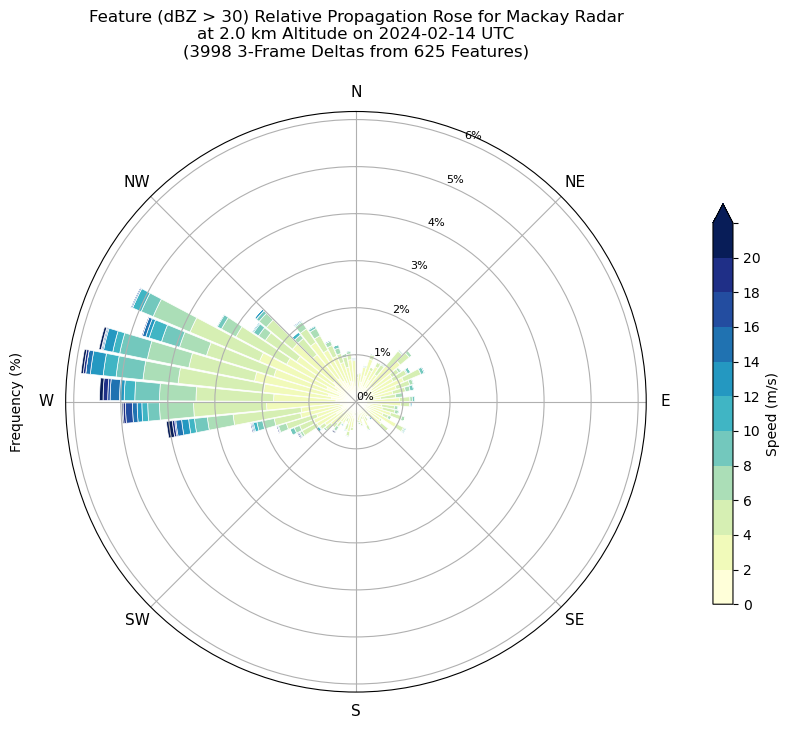

In [17]:
# NEW PROPOGATION ROSE
# CHAD VERSION LOADED FROM NET CDF

# ── PROPAGATION ROSE FROM FeaturesXR (3-frame deltas, clean motion) ──────────

cmap_name         = 'YlGnBu'
figsize           = (8, 8)
min_frames        = 4       # must have at least this many frames to contribute
NumDirectionBins  = 64       # number of equal directional bins
RealColourBarMax  = 20      # m/s — top of the colourbar, everything above goes in '>max' bin

ColourBarMax = RealColourBarMax * (11/10) # REAl MAX is the top label, COlourBarMax is what it would normally be if labelled

# ── extract arrays from FeaturesXR ───────────────────────────────────────────
time_coords  = pd.to_datetime(FeaturesXR['time'].values)
feature_ids  = FeaturesXR['feature_id'].values
centre_x     = FeaturesXR['centre_x_km'].values
centre_y     = FeaturesXR['centre_y_km'].values
motion_clean = FeaturesXR['motion_clean'].values

n_times    = len(time_coords)
n_features = len(feature_ids)

# ── time differences between consecutive frames in seconds ────────────────────
dt_seconds = np.array([
    (time_coords[i+1] - time_coords[i]).total_seconds()
    for i in range(n_times - 1)
])

# ── collect 3-frame delta vectors ─────────────────────────────────────────────
all_u         = []
all_v         = []
features_used = set()
n_deltas      = 0

for f_idx in range(n_features):

    alive_mask  = np.isfinite(centre_x[:, f_idx])
    alive_tidxs = np.where(alive_mask)[0]

    if len(alive_tidxs) < min_frames:
        continue

    for k in range(len(alive_tidxs) - 3):
        t0 = alive_tidxs[k]
        t1 = alive_tidxs[k + 1]
        t2 = alive_tidxs[k + 2]
        t3 = alive_tidxs[k + 3]

        # Frames must be consecutive
        if not (t1 == t0+1 and t2 == t0+2 and t3 == t0+3):
            continue

        # All 4 frames must have clean motion
        if not all(motion_clean[ti, f_idx] == 1.0 for ti in [t0, t1, t2, t3]):
            continue

        dt_total = dt_seconds[t0] + dt_seconds[t1] + dt_seconds[t2]
        if dt_total <= 0:
            continue

        dx_m = (centre_x[t3, f_idx] - centre_x[t0, f_idx]) * 1000.0
        dy_m = (centre_y[t3, f_idx] - centre_y[t0, f_idx]) * 1000.0

        all_u.append(dx_m / dt_total)
        all_v.append(dy_m / dt_total)
        features_used.add(int(feature_ids[f_idx]))
        n_deltas += 1

MeanUwind = -4.54
MeanVwind = -0.747

all_u = np.array(all_u)
all_v = np.array(all_v)

# all_u_plot = all_u
# all_v_plot = all_v

all_u_plot = all_u - MeanUwind
all_v_plot = all_v - MeanVwind

n_features_used = len(features_used)
print(f"Total 3-frame deltas : {n_deltas}")
print(f"Features contributing: {n_features_used}")

# ── convert U/V to speed and direction ────────────────────────────────────────
speeds     = np.sqrt(all_u_plot**2 + all_v_plot**2)
directions = (np.degrees(np.arctan2(all_u_plot, all_v_plot)) + 180.0) % 360.0 # SHIFT BY 180 TO BE IN LINE WITH WIND ROSE DIRECTIONS (E is towards the West)


# ── derive speed bins from ColourBarMax ───────────────────────────────────────
# Always 11 colours: 10 equal bins from 0 to ColourBarMax, plus '>max'
bin_width    = ColourBarMax / 11
speed_edges  = np.arange(0, ColourBarMax + bin_width, bin_width)   # 11 edges → 10 bins
n_speed_bins = len(speed_edges) - 1                              
speed_labels = [f'{speed_edges[i]:.4g}–{speed_edges[i+1]:.4g} m/s'
                for i in range(n_speed_bins - 1)]
speed_labels.append(f'>{int(ColourBarMax)} m/s')

speeds_clipped = np.clip(speeds, 0, speed_edges[-1] - 1e-6)

# ── define directional bins ───────────────────────────────────────────────────
# NumDirectionBins equal sections starting at 0 degrees (North)
dir_width   = 360.0 / NumDirectionBins
dir_centres = np.arange(0, 360, dir_width)          # bin centres
dir_starts  = dir_centres                            # bins start at 0, dir_width, 2*dir_width...

# Always label the 8 cardinal directions regardless of NumDirectionBins
# Place labels at the nearest bin centre to each cardinal direction
cardinal_angles = np.array([0, 45, 90, 135, 180, 225, 270, 315])
cardinal_labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

# ── bin the data ──────────────────────────────────────────────────────────────
counts = np.zeros((NumDirectionBins, n_speed_bins))

for i in range(NumDirectionBins):
    low  = dir_starts[i]
    high = (dir_starts[i] + dir_width) % 360.0

    if low > high:
        dir_mask = (directions >= low) | (directions < high)
    else:
        dir_mask = (directions >= low) & (directions < high)

    dir_speeds = speeds_clipped[dir_mask]

    for j in range(n_speed_bins):
        speed_mask   = (dir_speeds >= speed_edges[j]) & (dir_speeds < speed_edges[j + 1])
        counts[i, j] = speed_mask.sum()

# Convert to percentage of total
total      = counts.sum()
counts_pct = (counts / total) * 100.0 if total > 0 else counts

# ── colourmap ─────────────────────────────────────────────────────────────────
cmap        = plt.get_cmap(cmap_name)
colour_vals = np.linspace(0.0, 1.0, n_speed_bins)
colours     = [cmap(v) for v in colour_vals]

# ── plot ──────────────────────────────────────────────────────────────────────
fig      = plt.figure(figsize=figsize)
ax_polar = fig.add_subplot(111, projection='polar')

ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)

# Bar width fills each directional bin, theta at bin centre
bar_width = np.radians(dir_width * 0.9)
theta     = np.radians(dir_centres + dir_width / 2.0)   # centre of each bin
bottoms   = np.zeros(NumDirectionBins)

for j in range(n_speed_bins):
    ax_polar.bar(
        theta,
        counts_pct[:, j],
        width     = bar_width,
        bottom    = bottoms,
        color     = colours[j],
        edgecolor = 'white',
        linewidth = 0.5,
        label     = speed_labels[j],
    )
    bottoms += counts_pct[:, j]

# ── axes formatting ───────────────────────────────────────────────────────────
# Place the 8 cardinal labels at their exact angles regardless of bin count
ax_polar.set_xticks(np.radians(cardinal_angles))
ax_polar.set_xticklabels(cardinal_labels, fontsize=11)

ax_polar.set_ylabel('Frequency (%)', labelpad=30, fontsize=10)

max_pct = bottoms.max()
r_ticks = np.arange(0, max_pct + 2, max(1, round(max_pct / 5)))
ax_polar.set_yticks(r_ticks)
ax_polar.set_yticklabels([f'{r:.0f}%' for r in r_ticks], fontsize=8)
ax_polar.set_ylim(0, max_pct * 1.05)

ax_polar.set_title(
    f'Feature (dBZ > {FeatureDBZmin}) Relative Propagation Rose for {RadarSiteName} Radar\n'
    f'at {Altitude*0.001} km Altitude on {RadarFileDatePrint} UTC\n'
    f'({n_deltas} 3-Frame Deltas from {n_features_used} Features)',
    pad=20, fontsize=12
)

# ── colourbar ─────────────────────────────────────────────────────────────────
bar_colours   = [cmap(v) for v in np.linspace(0.0, 1.0, n_speed_bins)]
over_colour   = cmap(1.0)
cmap_discrete = ListedColormap(bar_colours)
cmap_discrete.set_over(over_colour)

norm = mcolors.BoundaryNorm(speed_edges, n_speed_bins)
sm   = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax_polar, orientation='vertical',
                    pad=0.1, fraction=0.03, shrink=0.7,
                    boundaries=speed_edges, spacing='uniform',
                    extend='max')
cbar.set_label('Speed (m/s)')
cbar.set_ticks(speed_edges)
cbar.set_ticklabels([f'{e:.4g}' for e in speed_edges[:-1]] + [''])

plt.tight_layout()

# ── save ──────────────────────────────────────────────────────────────────────
SaveFolder = ('/scratch/v46/sg3241/tmp/pngImages/FeaturePropogation/' +
              RadarIDno + '/' + RadarFileDate + '/')

SaveFile   = (RadarIDno + '_' + RadarFileDate + '_' +
              str(int(FeatureDBZmin)) + 'DBZmin_' +
              str(NumDirectionBins) + 'DirBins_' +
              str(int(ColourBarMax)) + 'msMax_' +
              '3FrameDeltaRelativePropogationRose_' + str(Altitude) + 'm.png')

SavePath = SaveFolder + SaveFile

if not Path(SaveFolder).exists():
    Path(SaveFolder).mkdir(parents=True, exist_ok=True)

# plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi=300)
# plt.close()


In [ ]:
# CHAD CREATED FEATURE BIRTH LOCATIONS MAP

PlotType = 'density' # 'scatter' for time-of-day coloured scatter plot or 'density' for kernel density contours

# ── extract birth locations and times ─────────────────────────────────────────
time_coords  = pd.to_datetime(FeaturesXR['time'].values)
born_arr     = FeaturesXR['born'].values          # (n_times, n_features)
centre_lat   = FeaturesXR['centre_lat'].values    # (n_times, n_features)
centre_lon   = FeaturesXR['centre_lon'].values    # (n_times, n_features)

birth_lats   = []
birth_lons   = []
birth_mins   = []   # time of day in minutes for colouring

for t_idx, ts in enumerate(time_coords):
    # Find all features born at this timestep
    born_mask = born_arr[t_idx, :] == 1.0
    if not np.any(born_mask):
        continue
    lats = centre_lat[t_idx, born_mask]
    lons = centre_lon[t_idx, born_mask]
    # Time of day in minutes
    minutes = ts.hour * 60 + ts.minute + ts.second / 60.0
    for lat, lon in zip(lats, lons):
        if np.isfinite(lat) and np.isfinite(lon):
            birth_lats.append(lat)
            birth_lons.append(lon)
            birth_mins.append(minutes)

birth_lats = np.array(birth_lats)
birth_lons = np.array(birth_lons)
birth_mins = np.array(birth_mins)

print(f"Plotting {len(birth_lats)} feature birth locations.")

# ── set up figure with topo background ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6),
                       subplot_kw={'projection': ccrs.PlateCarree()})

lon_min = float(np.nanmin(centre_lon[np.isfinite(centre_lon)]))
lon_max = float(np.nanmax(centre_lon[np.isfinite(centre_lon)]))
lat_min = float(np.nanmin(centre_lat[np.isfinite(centre_lat)]))
lat_max = float(np.nanmax(centre_lat[np.isfinite(centre_lat)]))

# ── topo background ───────────────────────────────────────────────────────────
try:
    gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'
    dem_da     = fetch_gebco_local(gebco_path, lon_min, lon_max, lat_min, lat_max)

    if dem_da is not None:
        dem_lon  = dem_da.lon.values
        dem_lat  = dem_da.lat.values
        dem_data = dem_da.values

        if dem_lon.ndim == 1 and dem_lat.ndim == 1:
            dem_lon_2d, dem_lat_2d = np.meshgrid(dem_lon, dem_lat)
        else:
            dem_lon_2d, dem_lat_2d = dem_lon, dem_lat

        if not np.any(np.isfinite(dem_data)):
            raise ValueError('DEM has no finite values in this domain')

        colours_topo = [
            '#dde4e8',
            '#c4dec2',
            '#e4edc9',
            '#f3f0cf',
            '#e9d7bd',
            '#ddc4aa',
            '#cfb194',
            '#b58f6e',
        ]
        bounds_topo = [-1000.0, 0.0, 200.0, 400.0, 600.0, 800.0, 1000.0, 1200.0, 5000.0]

        cmap_elev = ListedColormap(colours_topo)
        norm_topo = BoundaryNorm(bounds_topo, len(colours_topo), clip=True)

        ax.pcolormesh(
            dem_lon_2d, dem_lat_2d, dem_data,
            cmap      = cmap_elev,
            norm      = norm_topo,
            alpha     = 1.0,
            transform = ccrs.PlateCarree(),
        )
        ax.contour(
            dem_lon_2d, dem_lat_2d, dem_data,
            levels    = [0.0],
            colors    = 'black',
            linewidths= 0.5,
            transform = ccrs.PlateCarree(),
            zorder    = 15,
        )
        ax.contour(
            dem_lon_2d, dem_lat_2d, dem_data,
            levels    = [400.0],
            colors    = 'black',
            linewidths= 0.3,
            transform = ccrs.PlateCarree(),
            zorder    = 15,
        )
        print('Terrain shading loaded successfully')
    else:
        raise ValueError('GEBCO DEM returned None')

except Exception as e:
    print(f'Terrain shading failed: {e}')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3, zorder=1)
    ax.add_feature(cfeature.LAND,  facecolor='#E8E8E8',   alpha=0.3, zorder=2)

ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5, zorder=3)

if (PlotType == 'scatter'):
    # ── plot birth locations coloured by time of day ──────────────────────────────
    sc = ax.scatter(
        birth_lons, birth_lats,
        c          = birth_mins,
        cmap       = plt.get_cmap('nipy_spectral'),
        vmin       = 0,
        vmax       = 1440,
        s          = 6,             # ← smaller dots
        alpha      = 0.8,
        transform  = ccrs.PlateCarree(),
        zorder     = 25,
        edgecolors = 'none',
    )

elif (PlotType == 'density'):
    # ── kernel density estimate of birth locations ────────────────────────────────
    xy          = np.vstack([birth_lons, birth_lats])
    kde         = gaussian_kde(xy, bw_method=0.1)
    
    lon_grid    = np.linspace(lon_min, lon_max, 300)
    lat_grid    = np.linspace(lat_min, lat_max, 300)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
    grid_coords = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])
    
    kde_values  = kde(grid_coords).reshape(lon_mesh.shape)
    
    # ── convert KDE density to births per 100 km² per day ────────────────────────
    # KDE output units: probability density per degree²
    # 1 degree latitude  ≈ 111.32 km
    # 1 degree longitude ≈ 111.32 * cos(mean_lat) km
    mean_lat      = np.mean(birth_lats)
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.radians(mean_lat))
    km2_per_deg2   = km_per_deg_lat * km_per_deg_lon   # km² per degree²
    
    # Multiply density (per deg²) by km² per deg² to get per km²
    # Multiply by n_births to get births per km²
    # Multiply by 100 to get births per 100 km²
    n_births       = len(birth_lats)
    kde_births_per_100km2 = (kde_values / km2_per_deg2) * n_births * 100.0
    
    # ── shaded KDE fill ───────────────────────────────────────────────────────────
    levels_fill = np.arange(0, 62.5, 2.5)
    
    # Full range plot — used only to drive the colourbar, fully transparent
    kde_fill = ax.contourf(
        lon_mesh, lat_mesh, kde_births_per_100km2,
        levels    = levels_fill,
        cmap      = 'jet',
        alpha     = 0.0,             # invisible — just for colourbar
        transform = ccrs.PlateCarree(),
        zorder    = 24,
        extend    = 'max',
    )
    
    # Visible plot — only shows values >= 5
    kde_fill_visible = ax.contourf(
        lon_mesh, lat_mesh, kde_births_per_100km2,
        levels    = np.arange(2.5, 62.5, 2.5),   # starts at 5, skips the 0-5 bin
        cmap      = 'jet',
        alpha     = 0.5,
        transform = ccrs.PlateCarree(),
        zorder    = 24,
        extend    = 'max',
    )
    
    # ── colourbar ─────────────────────────────────────────────────────────────────
    cax = fig.add_axes([
        ax.get_position().x1 + 0.025,
        ax.get_position().y0 - 0.025,
        0.02,
        ax.get_position().height
    ])
    
    # Use a ScalarMappable with the full 0-100 range so the colourbar
    # shows the complete scale even though the 0-5 bin is not plotted
    sm = plt.cm.ScalarMappable(
        cmap = 'jet',
        norm = plt.Normalize(vmin=0, vmax=60)
    )
    sm.set_array([])
    
    cbar = plt.colorbar(sm, cax=cax, orientation='vertical', extend='max')
    cbar.set_label('Feature Births per 100 km² per day', fontsize=9)
    cbar.set_ticks(np.arange(0, 62.5, 2.5))
    ticks = np.arange(0, 62.5, 2.5)
    
    cbar.set_ticklabels([
        f'{int(v)}' if i % 2 == 0 else ''
        for i, v in enumerate(ticks)
    ])

    cbar.ax.tick_params(labelsize=8)

else:
    print("PlotType must be exactly 'scatter' or 'density' as a string")

# ── gridlines ─────────────────────────────────────────────────────────────────
gl_minor = ax.gridlines(draw_labels=False, alpha=0.8, zorder=11, linewidth=0.2)
gl_minor.xlocator = mticker.MultipleLocator(0.1)
gl_minor.ylocator = mticker.MultipleLocator(0.1)

gl_mid = ax.gridlines(draw_labels=True, alpha=0.8, zorder=12, linewidth=0.3)
gl_mid.xlocator = mticker.MultipleLocator(0.5)
gl_mid.ylocator = mticker.MultipleLocator(0.5)

gl_major = ax.gridlines(draw_labels=True, alpha=0.8, zorder=13, linewidth=0.6)
gl_major.xlocator = mticker.MultipleLocator(1.0)
gl_major.ylocator = mticker.MultipleLocator(1.0)

gl_mid.xformatter = LONGITUDE_FORMATTER
gl_mid.yformatter = LATITUDE_FORMATTER
gl_major.xformatter = LONGITUDE_FORMATTER
gl_major.yformatter = LATITUDE_FORMATTER

gl_mid.top_labels   = False
gl_mid.right_labels = False
gl_major.top_labels   = False
gl_major.right_labels = False

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

if (PlotType == 'scatter'):
    ax.set_title(
        f'Feature (dBZ > {FeatureDBZmin}) "Birth" Locations for {RadarSiteName} Radar\n'
        f'at {Altitude*0.001} km Altitude on {RadarFileDatePrint} UTC\n'
        f'({len(birth_lats)} Features)',
        fontsize=12
    )

    SaveFile   = (RadarIDno + '_' + RadarFileDate + '_' +
              str(int(FeatureDBZmin)) + 'DBZmin_BirthLocations_' + str(Altitude) + 'm.png')

        # ── time of day colourbar ─────────────────────────────────────────────────────
    cax = fig.add_axes([
        ax.get_position().x1 + 0.025,    # just right of the map
        ax.get_position().y0 + 0.025,            # bottom aligned with map
        0.02,                            # width
        ax.get_position().height         # full height of map
    ])
    
    cbar = plt.colorbar(sc, cax=cax, orientation='vertical')
    cbar.set_label('Birth Time (UTC)')
    
    hourly_ticks = np.arange(0, 1441, 60)
    cbar.set_ticks(hourly_ticks)
    tick_labels = [
        f'{int(m // 60):02d}:00' if m % 180 == 0 else ''
        for m in hourly_ticks
    ]
    cbar.set_ticklabels(tick_labels)
    cbar.ax.tick_params(which='major', length=4, width=0.8)

elif (PlotType == 'density'):
    ax.set_title(
        f'Feature (dBZ > {FeatureDBZmin}) "Birth" Locations Density for {RadarSiteName} Radar\n'
        f'at {Altitude*0.001} km Altitude on {RadarFileDatePrint} UTC\n'
        f'({len(birth_lats)} Features)',
        fontsize=12
    )

    SaveFile   = (RadarIDno + '_' + RadarFileDate + '_' +
              str(int(FeatureDBZmin)) + 'DBZmin_BirthLocationDensity_' + str(Altitude) + 'm.png')
else:
    print("PlotType must be exactly 'scatter' or 'density' as a string")


plt.tight_layout()

# ── save ──────────────────────────────────────────────────────────────────────
SaveFolder = ('/scratch/v46/sg3241/tmp/pngImages/FeatureTracks/' +
              RadarIDno + '/' + RadarFileDate + '/')
SavePath   = SaveFolder + SaveFile

if not Path(SaveFolder).exists():
    Path(SaveFolder).mkdir(parents=True, exist_ok=True)

plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi=300)
plt.close()
print(f"Saved to {SavePath}")


In [ ]:
# LOAD THE FEATURE STATS SUMMARY AS A CSV
SavedFolder = '/scratch/v46/sg3241/tmp/FeatureStats/' + RadarIDno + '/' + RadarFileDate + '/'
SavedFile = RadarIDno + '_' + RadarFileDate + '_' + str(int(FeatureDBZmin)) + 'DBZmin_' + str(Altitude) + 'm_summary.csv'
    
SavedPath = SavedFolder + SavedFile

summary = pd.read_csv(SavedPath)

In [ ]:
# COMBINE ALL OF THE DATA FRAMES FROM EACH TIME AT ONE LEVEL INTO ONE BIG DATA FRAME

# CHOOSE COMPRESSED OR UNCOMRESSED FILES
CompBool = 1     # 1 for yes compressed, 0 for no, uncompressed files

# CHOOSE THE RADAR
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Brisbane)

# CHOOSE THE DATE
# the day in consideration (YYYYMMDD) and time (hhmmss)       ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 2
RadarDay   = 25
# CHOOSE THE MINUTES YOU WANT TO LOOP OVER (5-MIN PERIODS) (INCLUSIVE OF START AND END TIMES)
LoopStartTime = '00:00'
LoopEndTime   = '23:55'

# CHOOSE YOUR ALTITUDE
Altitude = 6000  # [m] choose a multiple of 500 m to look at a CAPI for

# CHOOSE YOUR VARIABLE
Var = 'Z'
# LIST OF POSSIBLE VARIABLES
# [Z]         'corrected_reflectivity'
# [CC]        'corrected_cross_correlation_ratio'
# [ZDR]       'corrected_differential_reflectivity'
# [KDP]       'corrected_specific_differential_phase'
# [PhiDP]     'corrected_differential_phase'
...
# [V]         'corrected_velocity'

# VARIABLES NOT YET INCLUDED IN THE CODE
# [IntAtt]    'path_integrated_attenuation'
# [DifIntAtt] 'path_integrated_differential_attenuation'
# [EchClas]   'radar_echo_classification'
...
# [AzSh]      'azshear'



# CHOOSE YOUR QUALITY CONTROL SETTINGS
# taken from Aragon et al. 2024
MinValidZDR = -4 # NO VALID DATA TO USE THE OPTION YET
MaxValidZDR =  4 # NO VALID DATA TO USE THE OPTION YET
MinValidRhoHV = 0.85





# USER CHOICE FOLLOW-ON SECTION

# compression choice follow-on (select the folder to load from)
if (CompBool):
    RadarGridsFolder = 'CompressedRadarGrids'
else:
    RadarGridsFolder = 'RadarGrids'  

# radar choice follow-on
if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno


# date choice follow-on
# add leading zeros for strings
YYYY = str(RadarYear).zfill(4)
MM = str(RadarMonth).zfill(2)
DD = str(RadarDay).zfill(2)
# write out the data in one string with and without dashes
RadarFileDate  = YYYY + MM + DD
RadarFileDatePrint = YYYY + '-' + MM + '-' + DD


# variable choice follow-on
if (Var == 'Z'):
    VarName     = 'Reflectivity'
    VarNameLong = 'corrected_reflectivity'
    VarMinVal =  -10 # [dBZ]
    VarMaxVal =   65 # [dBZ]
    VarUnit   = 'dBZ'
    VarColourBar = make_ChadMapZ()
    # fix the colour bar to all values no matter which range you choose to view
    VarColourBar_min = -30.0
    VarColourBar_max = 100.0
    VarColourBar_norm = Normalize(vmin=VarColourBar_min, vmax=VarColourBar_max)

elif (Var == 'ZDR'):
    VarName     = 'Differential Reflectivity'
    VarNameLong = 'corrected_differential_reflectivity'
    VarMinVal = -5 # [dB]
    VarMaxVal =  5 # [dB]
    VarUnit   = 'dB'
    VarColourBar = 'RdBu'
elif (Var == 'CC'):
    VarName     = 'Correlation Coefficient'
    VarNameLong = 'corrected_cross_correlation_ratio'
    VarMinVal = 0.8 # [0 to 1]
    VarMaxVal = 1.0 # [0 to 1]
    VarUnit   = '-0 to 1'
    VarColourBar = 'nipy_spectral'
elif (Var == 'KDP'):
    VarName     = 'Specific Differential Phase'
    VarNameLong = 'corrected_specific_differential_phase'
    VarMinVal = 0  # [deg/ km]
    VarMaxVal = 10 # [deg / km]
    VarUnit   = 'deg / km'
    VarColourBar = 'nipy_spectral'
elif (Var == 'PhiDP'):
    VarName     = 'Differential Phase'
    VarNameLong = 'corrected_differential_phase'
    VarMinVal = 0  # [deg]
    VarMaxVal = 30 # [deg]
    VarUnit   = 'deg'
    VarColourBar = 'nipy_spectral'
elif (Var == 'V'):
    VarName     = 'Velocity'
    VarNameLong = 'corrected_velocity'
    VarMinVal = -30 # [m/s]
    VarMaxVal =  30 # [m/s]
    VarUnit   = 'm/s'
    VarColourBar = 'RdBu_r'
else:
    raise ValueError("Input Variable '" + Var + "' not available\n" + "Please choose from the following list:\n" + \
          "[Z] 'corrected_reflectivity', [CC] 'corrected_cross_correlation_ratio', [ZDR] 'corrected_differential_reflectivity'\n" + \
          "[KDP] 'corrected_specific_differential_phase', [PhiDP] 'corrected_differential_phase'")

    

# remember these plots are horizontal cross sections
PlotType = 'Horz'

# LOOP OVER EVERY 5 MIN PERIOD IN THE DAY
# Parse start and end times
StartHour, StartMin = int(LoopStartTime.split(':')[0]), int(LoopStartTime.split(':')[1])
EndHour, EndMin     =   int(LoopEndTime.split(':')[0]),   int(LoopEndTime.split(':')[1])

# Convert to total minutes for easy comparison
StartMinOfDay = StartHour * 60 + StartMin
EndMinOfDay = EndHour * 60 + EndMin

# Initialize a list to store time slices
time_slices = []
time_coords = []

for MinOfDay in range(StartMinOfDay, EndMinOfDay + 1, 5):
    # find the old indicies with which this code was written (0-23 for hours, 0-11 for 5-minute periods within hours)
    houri = MinOfDay // 60
    mini  = MinOfDay % 60
        
    RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
    # add a string of format hh:mm:ss for printing
    RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] 
    
    print('working on ' + RadarFileTimePrint)

    NetCDFstoragePath = ('/scratch/v46/sg3241/tmp/NetCDFs/' + RadarGridsFolder + '/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/'
                                                             + RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc')
    # try to load in the netcdf file and if it doesn't work, just keep going through the loop
    try:
        xgrid = xr.open_dataset(NetCDFstoragePath)
    except FileNotFoundError:
        print(f'File missing for {RadarFileTimePrint}, skipping: {NetCDFstoragePath}')
        continue

    # index in the netcdf altitude variable for the altitude you want
    alti = np.where(xgrid.z == Altitude) # this is a double nested array for some reason
    alti = alti[0][0] # take the index out of the double nested array

    # quit out if the altitude does not correspond to one in the netCDF file
    if (np.size(alti) != 1): 
        raise ValueError(str(Altitude) + ' m is not a valid altitude in the data')

    # Extract corrected_reflectivity at this altitude and time
    # Shape: (301, 301, 1) — we'll squeeze out the time dimension later
    reflectivity_slice = xgrid['corrected_reflectivity'].isel(z=alti, time=0)
    
    time_slices.append(reflectivity_slice)
    time_coords.append(xgrid.time.values[0])

# Concatenate all time slices along the time dimension
xgrid_combined = xr.concat(time_slices, dim='time')

# Assign the correct time coordinates
xgrid_combined = xgrid_combined.assign_coords(time=time_coords)

# Rename to preserve the variable name
xgrid_combined = xgrid_combined.to_dataset(name='corrected_reflectivity')

print(f'Combined xarray shape: {xgrid_combined["corrected_reflectivity"].shape}')
# Expected output: (301, 301, 288)

In [ ]:
# Run tracker and get NetCDF dataset
FeatureDBZmin = 30.0

FeaturesXR = track_reflectivity_features_to_xr(
    xgrid_combined,
    threshold_dbz     = FeatureDBZmin,
    overlap_threshold = 0.20,
)

# # Save to disk
# save_features_xr(FeaturesXR, 'features_mackay_20240214.nc')

# # Load back later
# FeaturesXR = load_features_xr('features_mackay_20240214.nc')

# # Access a variable
# area = FeaturesXR['area_km2']   # shape (n_times, max_feature_id)

# # Get all living features at timestep 0
# t0 = FeaturesXR.isel(time=0)
# living = t0.where(t0['born'].notnull(), drop=True)

In [ ]:
# Save NetCDF
NetCDFsaveFolder = f'/scratch/v46/sg3241/tmp/NetCDFs/FeatureStats/{RadarIDno}/{RadarFileDate}/'
NetCDFsaveFile = f'{RadarIDno}_{RadarFileDate}_{int(FeatureDBZmin)}DBZmin_{Altitude}m_AllStats.nc'
NetCDFsavePath = NetCDFsaveFolder + NetCDFsaveFile

if not Path(NetCDFsaveFolder).exists():
    print('Creating Folder: ' + NetCDFsaveFolder)
    Path(NetCDFsaveFolder).mkdir(parents=True, exist_ok=True)
    

save_features_xr(FeaturesXR, NetCDFsavePath)

In [ ]:
# CHAD PLOT FOR BORN

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

# ── extract born array and timestamps ─────────────────────────────────────────
born_array  = FeaturesXR['died'].values          # shape (n_times, n_features)
timestamps  = pd.to_datetime(FeaturesXR['time'].values)

# ── custom colourmap: white=NaN, gray=0, black=1 ─────────────────────────────
cmap        = mcolors.ListedColormap(['gray', 'black'])
norm        = mcolors.BoundaryNorm([0, 0.5, 1.5], cmap.N)
born_masked = np.ma.masked_invalid(born_array)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.pcolormesh(
    timestamps,
    np.arange(born_array.shape[1]),   # feature_id on y
    born_masked.T,
    cmap = cmap,
    norm = norm,
)

# ── x axis formatting ─────────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=15))
plt.xticks(rotation=45, ha='right')

# Set x limits to exactly 00:00 to 00:00 (midnight to midnight)
day_start = pd.Timestamp(timestamps[0].date())
day_end   = day_start + pd.Timedelta(days=1)
ax.set_xlim(day_start, day_end)

ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Feature ID')
ax.set_title(f'Feature "Born" Flag — {day_start.strftime("%Y-%m-%d")}\n(black=1, gray=0, white=NaN)')

# ── simple legend ─────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='black', label='Born (1)'),
    Patch(facecolor='gray',  label='Alive but not born (0)'),
    Patch(facecolor='white', edgecolor='black', label='Not alive (NaN)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()

SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/'
SaveFile   = 'BornPlot.png'
SavePath = SaveFolder + SaveFile

if not Path(SaveFolder).exists():
    print('Creating Folder: ' + SaveFolder)
    Path(SaveFolder).mkdir(parents=True, exist_ok=True)

# plt.close()
# plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)

In [ ]:
FeatureDBZmin = 30.0

In [ ]:
# Calculate feature stats at every time step

FeatureDBZmin = 30.0

results, all_labels = track_reflectivity_features(
    xgrid_combined,
    threshold_dbz     = FeatureDBZmin,
    overlap_threshold = 0.20)

In [ ]:
# create a summary of the features for the whole day
summary = summarise_features(results)

In [ ]:
# CHAD CREATED SCATTER PLOT OF FEATURE PROPOGATION DIRECTIONS

def plot_uv_scatter(results, clean_motion_only=False, cmap_name='nipy_spectral', figsize=(7, 7)):
    """
    Scatter plot of U vs V motion speeds for all features across all timesteps.
    Dots are coloured by time of day using a cyclic colourmap.

    Parameters
    ----------
    results : dict { timestamp : pd.DataFrame }
        Output from track_reflectivity_features().
    clean_motion_only : bool
        If True, only plot points where motion_clean == True.
    cmap_name : str
        Matplotlib colourmap name. Default is 'nipy_spectral'.
    figsize : tuple
        Figure size.
    """

    # ── collect all U/V pairs and timestamps across all timesteps ─────────────
    all_u          = []
    all_v          = []
    all_minutes    = []   # time of day in minutes for colouring

    for timestamp, df in results.items():
        if df.empty:
            continue

        valid = df[df['u_ms'].notna() & df['v_ms'].notna()].copy()

        if clean_motion_only:
            valid = valid[valid['motion_clean'] == True]

        if valid.empty:
            continue

        # Time of day in minutes for this timestep
        dt = pd.Timestamp(timestamp)
        minutes = dt.hour * 60 + dt.minute + dt.second / 60.0

        all_u.extend(valid['u_ms'].tolist())
        all_v.extend(valid['v_ms'].tolist())
        all_minutes.extend([minutes] * len(valid))

    all_u       = np.array(all_u)
    all_v       = np.array(all_v)
    all_minutes = np.array(all_minutes)

    print(f"Plotting {len(all_u)} U/V data points.")

    # ── plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        all_u, all_v,
        c          = all_minutes,
        cmap       = plt.get_cmap(cmap_name),
        vmin       = 0,
        vmax       = 1440,
        s          = 10,
        alpha      = 0.6,
        edgecolors = 'none',
    )

    # Zero lines for reference
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Equal axes
    max_val = np.nanmax(np.abs(np.concatenate([all_u, all_v]))) * 1.1
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ax.set_aspect('equal')

    # Labels
    ax.set_xlabel('U speed (m/s)  [West ← 0 → East]')
    ax.set_ylabel('V speed (m/s)  [South ← 0 → North]')
    title_suffix = ' (clean motion only)' if clean_motion_only else ' (all motion)'
    ax.set_title(f'Feature U–V Motion Scatter{title_suffix}\nn = {len(all_u)} points')

    # ── time of day colourbar ─────────────────────────────────────────────────
    cbar = plt.colorbar(sc, ax=ax, orientation='vertical',
                        pad=0.02, fraction=0.046, shrink=1.0)
    cbar.set_label('Time of Day (UTC)')

    hourly_ticks = np.arange(0, 1441, 60)
    cbar.set_ticks(hourly_ticks)
    tick_labels = [
        f'{int(m // 60):02d}:00' if m % 180 == 0 else ''
        for m in hourly_ticks
    ]
    cbar.set_ticklabels(tick_labels)
    cbar.ax.tick_params(which='major', length=4, width=0.8)

    plt.xlim([-10,10])
    plt.ylim([-10,10])

    plt.tight_layout()
    plt.show()

    return fig, ax




In [ ]:
# CHAD WIND ROSE

# results = results
clean_motion_only=True
cmap_name='plasma'
figsize=(8, 8)

min_lifetime_minutes = 12   # only features alive longer than this are included
# (please make this an integer)


# # ── collect U/V speeds and weights ───────────────────────────────────────
# all_u       = []
# all_v       = []
# all_weights = []

# for timestamp, df in results.items():
#     if df.empty:
#         continue

#     # Must have valid speed AND a valid previous mass to weight by
#     valid = df[
#         df['u_ms'].notna() &
#         df['v_ms'].notna() &
#         df['prev_mass_dBZkm2'].notna()
#     ].copy()

#     if clean_motion_only:
#         valid = valid[valid['motion_clean'] == True]

#     if valid.empty:
#         continue

#     all_u.extend(valid['u_ms'].tolist())
#     all_v.extend(valid['v_ms'].tolist())
#     all_weights.extend(valid['prev_mass_dBZkm2'].tolist())

# all_u       = np.array(all_u)
# all_v       = np.array(all_v)
# all_weights = np.array(all_weights)

# print(f"Plotting {len(all_u)} propagation vectors (weighted by prev_mass_dBZkm2).")

# SUMMARY VERSION
# SUMMARY VERSION
# SUMMARY VERSION
# SUMMARY VERSION
# ── filter summary by minimum lifetime ───────────────────────────────────
min_lifetime_seconds = min_lifetime_minutes * 60
summary_filtered     = summary[summary['time_alive_s'] > min_lifetime_seconds]

print(f"Features before lifetime filter : {len(summary)}")
print(f"Features after lifetime filter  : {len(summary_filtered)} (> {min_lifetime_minutes} min)")

# ── collect U/V speeds and weights from filtered summary ─────────────────
valid_mask  = summary_filtered['mean_u_ms'].notna() & summary_filtered['mean_v_ms'].notna()
all_u       = summary_filtered.loc[valid_mask, 'mean_u_ms'].values
all_v       = summary_filtered.loc[valid_mask, 'mean_v_ms'].values
all_weights = summary_filtered.loc[valid_mask, 'time_alive_s'].values #* \
           #   summary_filtered.loc[valid_mask, 'mean_area_km2'].values


print(f"Plotting {len(all_u)} feature mean propagation vectors (time_alive_s).") #weighted by mean_area_km2 × 
# SUMMARY VERSION END
# SUMMARY VERSION END
# SUMMARY VERSION END
# SUMMARY VERSION END

# ── convert U/V to speed and direction ────────────────────────────────────
speeds     = np.sqrt(all_u**2 + all_v**2)
directions = (np.degrees(np.arctan2(all_u, all_v))) % 360.0

# ── define bins ───────────────────────────────────────────────────────────
dir_labels  = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
n_dirs      = 8
dir_width   = 360.0 / n_dirs
dir_centres = np.arange(0, 360, dir_width)

speed_edges  = np.arange(0, 12, 1)          # [0, 2, 4, ... 20]
n_speed_bins = len(speed_edges) - 1
speed_labels = [f'{int(speed_edges[i])}–{int(speed_edges[i+1])} m/s'
                for i in range(n_speed_bins - 1)]
speed_labels.append('>20 m/s')

speeds_clipped = np.clip(speeds, 0, 11.0 - 1e-6)

# ── bin the data — sum weights instead of counting ────────────────────────
# weighted_counts[dir_idx, speed_idx] = sum of prev_mass_dBZkm2 in that bin
weighted_counts = np.zeros((n_dirs, n_speed_bins))

for i in range(n_dirs):
    centre = dir_centres[i]
    low    = (centre - dir_width / 2.0) % 360.0
    high   = (centre + dir_width / 2.0) % 360.0

    if low > high:
        dir_mask = (directions >= low) | (directions < high)
    else:
        dir_mask = (directions >= low) & (directions < high)

    dir_speeds  = speeds_clipped[dir_mask]
    dir_weights = all_weights[dir_mask]

    for j in range(n_speed_bins):
        speed_mask              = (dir_speeds >= speed_edges[j]) & (dir_speeds < speed_edges[j + 1])
        # Sum weights rather than count
        weighted_counts[i, j]  = dir_weights[speed_mask].sum()

# Convert to percentage of total weight
total_weight    = weighted_counts.sum()
counts_pct      = (weighted_counts / total_weight) * 100.0 if total_weight > 0 else weighted_counts

# ── colourmap for speed layers ─────────────────────────────────────────────
cmap        = plt.get_cmap(cmap_name)
colour_vals = np.linspace(0.0, 1.0, n_speed_bins)
colours     = [cmap(v) for v in colour_vals]

# ── plot ──────────────────────────────────────────────────────────────────
fig      = plt.figure(figsize=figsize)
ax_polar = fig.add_subplot(111, projection='polar')

ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)

bar_width = np.radians(dir_width * 0.9)
theta     = np.radians(dir_centres)

bottoms = np.zeros(n_dirs)

for j in range(n_speed_bins):
    ax_polar.bar(
        theta,
        counts_pct[:, j],
        width     = bar_width,
        bottom    = bottoms,
        color     = colours[j],
        edgecolor = 'white',
        linewidth = 0.5,
        label     = speed_labels[j],
    )
    bottoms += counts_pct[:, j]

# ── axes formatting ───────────────────────────────────────────────────────
ax_polar.set_xticks(np.radians(dir_centres))
ax_polar.set_xticklabels(dir_labels, fontsize=11)

ax_polar.set_ylabel('Weighted Frequency (%)', labelpad=30, fontsize=10)

max_pct = bottoms.max()
r_ticks = np.arange(0, max_pct + 2, max(1, round(max_pct / 5)))
ax_polar.set_yticks(r_ticks)
ax_polar.set_yticklabels([f'{r:.0f}%' for r in r_ticks], fontsize=8)
ax_polar.set_ylim(0, max_pct * 1.05)   # ← 15% headroom above the tallest bar

title_suffix = ' (clean motion only)' if clean_motion_only else ' (all motion)'
ax_polar.set_title(
    f'Feature (dBZ > {FeatureDBZmin}) Propagation Rose for {RadarSiteName} Radar\n at {Altitude*0.001} km Altitude'
    f' on {RadarFileDatePrint} UTC\n({len(all_u)} Features weighted by Mean Lifetime {title_suffix})\nConsidering Features Lasting > {min_lifetime_minutes} Mins',
    pad=20, fontsize=12 # Area and
)

# ── colourbar for speed — discretised to match wind rose bins ─────────────────
# Generate n_speed_bins colours for the bars + 1 extra darker colour for the
# >20 triangle so it is visually distinct from the 18-20 bin
colour_vals   = np.linspace(0.0, 1.0, n_speed_bins)
bar_colours   = [cmap(v) for v in colour_vals]
over_colour   = cmap(1.0)                        # darkest end of the colourmap

cmap_discrete = ListedColormap(bar_colours)
cmap_discrete.set_over(over_colour)              # triangle gets this distinct colour

norm = mcolors.BoundaryNorm(speed_edges, n_speed_bins)
sm   = plt.cm.ScalarMappable(cmap=cmap_discrete, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax_polar, orientation='vertical',
                    pad=0.1, fraction=0.03, shrink=0.7,
                    boundaries=speed_edges, spacing='uniform',
                    extend='max')
cbar.set_label('Speed (m/s)')
cbar.set_ticks(speed_edges)
cbar.set_ticklabels([f'{int(e)}' for e in speed_edges[:-1]] + [''])



plt.tight_layout()

SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/FeaturePropogation/' + RadarIDno + '/' + RadarFileDate + '/'
                                                                                    
SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + str(int(FeatureDBZmin)) + 'DBZmin_' + str(int(min_lifetime_minutes)) + 'MinsMin_SummaryPropogationRose_' + str(Altitude) + 'mLifetimeOnly.png'

SavePath = SaveFolder + SaveFile

if not Path(SaveFolder).exists():
    print('doing')
    Path(SaveFolder).mkdir(parents=True, exist_ok=True)

# plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
# plt.close()

In [ ]:
# DUMP ALL OF THE FEATURE STATS FROM EACH TIME INTO A PICKLE FILE TO READ IN LATER
import pickle

SaveFolder = '/scratch/v46/sg3241/tmp/FeatureStats/' + RadarIDno + '/' + RadarFileDate + '/'
SaveFile = RadarIDno + '_' + RadarFileDate + '_' + str(int(FeatureDBZmin)) + 'DBZmin_' + str(Altitude) + 'm_AllStats.pkl'
    
SavePath = SaveFolder + SaveFile

if not Path(SaveFolder).exists():
    print('doing')
    Path(SaveFolder).mkdir(parents=True, exist_ok=True)

with open(SavePath, 'wb') as f:
    pickle.dump(results, f)

In [ ]:
# LOAD THE FEATURE STATS BY TIME STEP AS A DICTIONARY
import pickle

SavedFolder = '/scratch/v46/sg3241/tmp/FeatureStats/' + RadarIDno + '/' + RadarFileDate + '/'
SavedFile = RadarIDno + '_' + RadarFileDate + '_' + str(int(FeatureDBZmin)) + 'DBZmin_' + str(Altitude) + 'm_AllStats.pkl'
    
SavedPath = SavedFolder + SavedFile

with open(SavedPath, 'rb') as f:
    results = pickle.load(f)

In [ ]:
# SAVE THE FEATURE STATS SUMMARY AS A CSV
SaveFolder = '/scratch/v46/sg3241/tmp/FeatureStats/' + RadarIDno + '/' + RadarFileDate + '/'
SaveFile = RadarIDno + '_' + RadarFileDate + '_' + str(int(FeatureDBZmin)) + 'DBZmin_' + str(Altitude) + 'm_summary.csv'
    
SavePath = SaveFolder + SaveFile

if not Path(SaveFolder).exists():
    print('doing')
    Path(SaveFolder).mkdir(parents=True, exist_ok=True)

summary.to_csv(SavePath, index=False)

In [ ]:
# CHAD CREATED FEATURE TRACKING PLOTTER

def plot_feature_tracks(ax, results, linewidth=1.5):
    """
    Plot centre-of-mass tracks for features that exist for more than one frame.

    Line colour is determined by the time-of-day of the segment's departure
    point, using a cyclic colourmap (HSV, 00:00→23:59 maps to 0→1).
    Line width is uniform.

    Parameters
    ----------
    ax : cartopy GeoAxes
    results : dict { timestamp : pd.DataFrame }
        Output from track_reflectivity_features().
    linewidth : float
        Uniform line width for all segments.
    """


    # ── cyclic time-of-day colourmap ──────────────────────────────────────────
    cmap = plt.get_cmap('hsv')

    def time_to_colour(timestamp):
        """
        Convert a numpy datetime64 timestamp to a colour based on time of day.
        00:00 → 0.0, 23:59 → ~1.0
        """
        dt = pd.Timestamp(timestamp)
        minutes_since_midnight = dt.hour * 60 + dt.minute + dt.second / 60.0
        normalised = minutes_since_midnight / 1440.0
        return plt.get_cmap('nipy_spectral')(normalised)

    # ── build per-feature time series ─────────────────────────────────────────
    all_ids = set()
    for df in results.values():
        all_ids.update(df['feature_id'].tolist())

    tracks = {fid: [] for fid in all_ids}

    for timestamp, df in results.items():
        for _, row in df.iterrows():
            tracks[row['feature_id']].append((
                timestamp,
                row['centre_lon'],
                row['centre_lat'],
            ))

    # Sort each track by timestamp
    for fid in tracks:
        tracks[fid].sort(key=lambda x: x[0])

    # ── plot only features with more than one timestep ────────────────────────
    for fid, track in tracks.items():
        if len(track) < 2:
            continue

        lons       = [entry[1] for entry in track]
        lats       = [entry[2] for entry in track]
        timestamps = [entry[0] for entry in track]

        for i in range(len(track) - 1):
            colour = time_to_colour(timestamps[i])
            ax.plot(
                [lons[i], lons[i + 1]],
                [lats[i], lats[i + 1]],
                color          = colour,
                linewidth      = linewidth,
                transform      = ccrs.PlateCarree(),
                zorder         = 20,
                alpha          = 0.85,
                solid_capstyle = 'round',
            )

In [ ]:
# TRACKS ON A MAP!

fig, ax = plt.subplots(figsize=(8, 6), 
                       subplot_kw={'projection': ccrs.PlateCarree()})

# gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'
# EXPERIMENTAL TOPO SHADING SECTION
# EXPERIMENTAL TOPO SHADING SECTION
# EXPERIMENTAL TOPO SHADING SECTION

# TERRAIN SHADING USING LOCAL GEBCO DEM
lon_min, lon_max = float(xgrid.lon.min()), float(xgrid.lon.max())
lat_min, lat_max = float(xgrid.lat.min()), float(xgrid.lat.max())

try:
    # Path to your GEBCO NetCDF
    gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'

    # Use the helper to get a subset over the radar domain
    dem_da = fetch_gebco_local(gebco_path, lon_min, lon_max, lat_min, lat_max)

    if dem_da is not None:
        # dem_da is an xarray.DataArray with coords lon, lat
        dem_lon = dem_da.lon.values
        dem_lat = dem_da.lat.values
        dem_data = dem_da.values

        # Make 2D lon/lat grids if necessary
        if dem_lon.ndim == 1 and dem_lat.ndim == 1:
            dem_lon_2d, dem_lat_2d = np.meshgrid(dem_lon, dem_lat)
        else:
            dem_lon_2d, dem_lat_2d = dem_lon, dem_lat

        # Ensure we have some valid data
        valid = np.isfinite(dem_data)
        if not np.any(valid):
            raise ValueError('DEM has no finite values in this domain')

        colours = [
            '#dde4e8',  # 0: pale blue-grey (ocean, < 0 m)
        
            '#c4dec2',  # 1: 0–200 m, pale green
            '#e4edc9',  # 2: 200–400 m, greenish-yellow
            '#f3f0cf',  # 3: 400–600 m, pale yellow-beige
            '#e9d7bd',  # 4: 600–800 m, light tan
            '#ddc4aa',  # 5: 800–1000 m, tan
            '#cfb194',  # 6: 1000–1200 m, light brown
            '#b58f6e',  # 7: > 1200 m, darker brown
        ]
        
        bounds = [
            -1000.0,  # ocean below 0
            0.0,      # 0–200
            200.0,    # 200–400
            400.0,    # 400–600
            600.0,    # 600–800
            800.0,    # 800–1000
            1000.0,   # 1000–1200
            1200.0,   # > 1200
            5000.0,
        ]
        
        cmap_elev = ListedColormap(colours)
        norm = BoundaryNorm(bounds, len(colours), clip=True)
        
        # Plot as semi‑transparent background
        elev_plot = ax.pcolormesh(
            dem_lon_2d,
            dem_lat_2d,
            dem_data,
            cmap=cmap_elev,
            norm=norm,
            alpha=1.0,
            transform=ccrs.PlateCarree(),
            # zorder=2,
        )

        # Draw 0 m contour as an accurate coastline
        coast_contour = ax.contour(
            dem_lon_2d,
            dem_lat_2d,
            dem_data,
            levels=[0.0],
            colors='black',
            linewidths=0.5,
            transform=ccrs.PlateCarree(),
            zorder=15,  # above radar and topo
        )

        # Draw 400 m contour
        coast_contour = ax.contour(
            dem_lon_2d,
            dem_lat_2d,
            dem_data,
            levels=[400.0],
            colors='black',
            linewidths=0.3,
            transform=ccrs.PlateCarree(),
            zorder=15,  # above radar and topo
        )

        print('Terrain shading (GEBCO, discrete bands) + coastline loaded successfully')

    else:
        raise ValueError('GEBCO DEM returned None')

except Exception as e:
    print(f'Terrain shading failed: {e}')
    print('Falling back to simple land/ocean shading')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3, zorder=1)
    ax.add_feature(cfeature.LAND, facecolor='#E8E8E8', alpha=0.3, zorder=2)

ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5, zorder=3)


# EXPERIMENTAL TOPO SHADING SECTION END
# EXPERIMENTAL TOPO SHADING SECTION END
# EXPERIMENTAL TOPO SHADING SECTION END

# Add MINOR gridlines (tenth degrees) - thin
gl_minor = ax.gridlines(draw_labels=False, alpha=0.8, zorder=11, linewidth=0.2)
gl_minor.xlocator = mticker.MultipleLocator(0.1)  # Every 0.1 degrees
gl_minor.ylocator = mticker.MultipleLocator(0.1)  # Every 0.1 degrees

# Add MID LEVEL gridlines (half degrees) - standard width with labels
gl_mid = ax.gridlines(draw_labels=True, alpha=0.8, zorder=12, linewidth=0.3)
gl_mid.xlocator = mticker.MultipleLocator(0.5)  # Every 0.5 degrees
gl_mid.ylocator = mticker.MultipleLocator(0.5)  # Every 0.5 degrees

# Add MAJOR gridlines (full degrees) - thick with labels
gl_major = ax.gridlines(draw_labels=True, alpha=0.8, zorder=13, linewidth=0.6)
gl_major.xlocator = mticker.MultipleLocator(1.0)  # Every 1.0 degrees
gl_major.ylocator = mticker.MultipleLocator(1.0)  # Every 1.0 degrees

# Format labels
gl_mid.xformatter = LONGITUDE_FORMATTER
gl_mid.yformatter = LATITUDE_FORMATTER

gl_major.xformatter = LONGITUDE_FORMATTER
gl_major.yformatter = LATITUDE_FORMATTER

# Remove labels from top and right
gl_mid.top_labels = False
gl_mid.right_labels = False
gl_mid.bottom_labels = True
gl_mid.left_labels = True

gl_major.top_labels = False
gl_major.right_labels = False
gl_major.bottom_labels = True
gl_major.left_labels = True

# # Add coastlines ON TOP of radar data
# ax.coastlines(resolution='10m', linewidth=0.5, color='black', zorder=13)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# CHAD CREATED CYCLICAL COLOUR MAP FOR TIME OF DAY

# ── time-of-day colourbar ─────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(
    cmap = plt.get_cmap('nipy_spectral'),
    norm = plt.Normalize(vmin=0, vmax=1440)   # minutes in a day
)
sm.set_array([])

plt.title('Feature Tracks (dBZ > ' + str(FeatureDBZmin) + ') for ' + RadarSiteName + ' Radar\nat ' + str(Altitude) + ' m Altitude on ' + \
          RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' UTC')

# ADD THIS TO MAKE THE COLOUR BAR PROPPER SIZE
from mpl_toolkits.axes_grid1 import make_axes_locatable

cax = fig.add_axes([
    ax.get_position().x1 + 0.06,   # left edge (just right of the map)
    ax.get_position().y0,           # bottom edge aligned with map
    0.02,                           # width
    ax.get_position().height        # height exactly matches map
])
# ADD THIS TO MAKE THE COLOUR BAR PROPPER SIZE END

cbar_time = plt.colorbar(sm, cax=cax, orientation='vertical')

# cbar_time = plt.colorbar(sm, ax=ax, orientation='vertical',
#                          pad=0.02, fraction=0.02, shrink=1.0)
cbar_time.set_label('Time of Day (UTC)')

# Tick every hour (every 60 minutes)
hourly_ticks = np.arange(0, 1441, 60)
cbar_time.set_ticks(hourly_ticks)

# Label only every 3 hours, blank string for the rest
tick_labels = [
    f'{int(m // 60):02d}:00' if m % 180 == 0 else ''
    for m in hourly_ticks
]
cbar_time.set_ticklabels(tick_labels)

# Make the hourly tick marks visible but keep 3-hourly labels readable
cbar_time.ax.tick_params(
    which  = 'major',
    length = 4,
    width  = 0.8,
)


plot_feature_tracks(ax, results)


plt.tight_layout()

SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/FeatureTracks/' + RadarIDno + '/' + RadarFileDate + '/'
                                                                                    
SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + str(int(FeatureDBZmin)) + '_FeatureTracks_' + str(Altitude) + 'm.png'

SavePath = SaveFolder + SaveFile

if not Path(SaveFolder).exists():
    print('doing')
    Path(SaveFolder).mkdir(parents=True, exist_ok=True)

plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
plt.close()

In [ ]:
# STRAIGHT LINE TRACKS ON A MAP!

fig, ax = plt.subplots(figsize=(8, 6), 
                       subplot_kw={'projection': ccrs.PlateCarree()})

# gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'
# EXPERIMENTAL TOPO SHADING SECTION
# EXPERIMENTAL TOPO SHADING SECTION
# EXPERIMENTAL TOPO SHADING SECTION

# TERRAIN SHADING USING LOCAL GEBCO DEM
lon_min, lon_max = float(xgrid.lon.min()), float(xgrid.lon.max())
lat_min, lat_max = float(xgrid.lat.min()), float(xgrid.lat.max())

try:
    # Path to your GEBCO NetCDF
    gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'

    # Use the helper to get a subset over the radar domain
    dem_da = fetch_gebco_local(gebco_path, lon_min, lon_max, lat_min, lat_max)

    if dem_da is not None:
        # dem_da is an xarray.DataArray with coords lon, lat
        dem_lon = dem_da.lon.values
        dem_lat = dem_da.lat.values
        dem_data = dem_da.values

        # Make 2D lon/lat grids if necessary
        if dem_lon.ndim == 1 and dem_lat.ndim == 1:
            dem_lon_2d, dem_lat_2d = np.meshgrid(dem_lon, dem_lat)
        else:
            dem_lon_2d, dem_lat_2d = dem_lon, dem_lat

        # Ensure we have some valid data
        valid = np.isfinite(dem_data)
        if not np.any(valid):
            raise ValueError('DEM has no finite values in this domain')

        colours = [
            '#dde4e8',  # 0: pale blue-grey (ocean, < 0 m)
        
            '#c4dec2',  # 1: 0–200 m, pale green
            '#e4edc9',  # 2: 200–400 m, greenish-yellow
            '#f3f0cf',  # 3: 400–600 m, pale yellow-beige
            '#e9d7bd',  # 4: 600–800 m, light tan
            '#ddc4aa',  # 5: 800–1000 m, tan
            '#cfb194',  # 6: 1000–1200 m, light brown
            '#b58f6e',  # 7: > 1200 m, darker brown
        ]
        
        bounds = [
            -1000.0,  # ocean below 0
            0.0,      # 0–200
            200.0,    # 200–400
            400.0,    # 400–600
            600.0,    # 600–800
            800.0,    # 800–1000
            1000.0,   # 1000–1200
            1200.0,   # > 1200
            5000.0,
        ]
        
        cmap_elev = ListedColormap(colours)
        norm = BoundaryNorm(bounds, len(colours), clip=True)
        
        # Plot as semi‑transparent background
        elev_plot = ax.pcolormesh(
            dem_lon_2d,
            dem_lat_2d,
            dem_data,
            cmap=cmap_elev,
            norm=norm,
            alpha=1.0,
            transform=ccrs.PlateCarree(),
            # zorder=2,
        )

        # Draw 0 m contour as an accurate coastline
        coast_contour = ax.contour(
            dem_lon_2d,
            dem_lat_2d,
            dem_data,
            levels=[0.0],
            colors='black',
            linewidths=0.5,
            transform=ccrs.PlateCarree(),
            zorder=15,  # above radar and topo
        )

        # Draw 400 m contour
        coast_contour = ax.contour(
            dem_lon_2d,
            dem_lat_2d,
            dem_data,
            levels=[400.0],
            colors='black',
            linewidths=0.3,
            transform=ccrs.PlateCarree(),
            zorder=15,  # above radar and topo
        )

        print('Terrain shading (GEBCO, discrete bands) + coastline loaded successfully')

    else:
        raise ValueError('GEBCO DEM returned None')

except Exception as e:
    print(f'Terrain shading failed: {e}')
    print('Falling back to simple land/ocean shading')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3, zorder=1)
    ax.add_feature(cfeature.LAND, facecolor='#E8E8E8', alpha=0.3, zorder=2)

ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5, zorder=3)


# EXPERIMENTAL TOPO SHADING SECTION END
# EXPERIMENTAL TOPO SHADING SECTION END
# EXPERIMENTAL TOPO SHADING SECTION END

# Add MINOR gridlines (tenth degrees) - thin
gl_minor = ax.gridlines(draw_labels=False, alpha=0.8, zorder=11, linewidth=0.2)
gl_minor.xlocator = mticker.MultipleLocator(0.1)  # Every 0.1 degrees
gl_minor.ylocator = mticker.MultipleLocator(0.1)  # Every 0.1 degrees

# Add MID LEVEL gridlines (half degrees) - standard width with labels
gl_mid = ax.gridlines(draw_labels=True, alpha=0.8, zorder=12, linewidth=0.3)
gl_mid.xlocator = mticker.MultipleLocator(0.5)  # Every 0.5 degrees
gl_mid.ylocator = mticker.MultipleLocator(0.5)  # Every 0.5 degrees

# Add MAJOR gridlines (full degrees) - thick with labels
gl_major = ax.gridlines(draw_labels=True, alpha=0.8, zorder=13, linewidth=0.6)
gl_major.xlocator = mticker.MultipleLocator(1.0)  # Every 1.0 degrees
gl_major.ylocator = mticker.MultipleLocator(1.0)  # Every 1.0 degrees

# Format labels
gl_mid.xformatter = LONGITUDE_FORMATTER
gl_mid.yformatter = LATITUDE_FORMATTER

gl_major.xformatter = LONGITUDE_FORMATTER
gl_major.yformatter = LATITUDE_FORMATTER

# Remove labels from top and right
gl_mid.top_labels = False
gl_mid.right_labels = False
gl_mid.bottom_labels = True
gl_mid.left_labels = True

gl_major.top_labels = False
gl_major.right_labels = False
gl_major.bottom_labels = True
gl_major.left_labels = True

# # Add coastlines ON TOP of radar data
# ax.coastlines(resolution='10m', linewidth=0.5, color='black', zorder=13)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# ── plot straight-line feature tracks from summary ────────────────────────────
# Colour lines by time of day of birth, using nipy_spectral
track_cmap = plt.get_cmap('nipy_spectral')

for _, row in summary.iterrows():
    # Skip single-frame features (no displacement)
    if row['n_timesteps'] < 2:
        continue

    # Colour by birth time of day in minutes
    dt         = pd.Timestamp(row['birth_t'])
    minutes    = dt.hour * 60 + dt.minute + dt.second / 60.0
    normalised = minutes / 1440.0
    colour     = track_cmap(normalised)

    ax.plot(
        [row['birth_lon'], row['death_lon']],
        [row['birth_lat'], row['death_lat']],
        color          = colour,
        linewidth      = 1.0,
        transform      = ccrs.PlateCarree(),
        zorder         = 20,
        alpha          = 0.7,
        solid_capstyle = 'round',
    )

    # Small dot at birth location
    ax.scatter(
        row['birth_lon'], row['birth_lat'],
        s         = 8,
        color     = colour,
        transform = ccrs.PlateCarree(),
        zorder    = 21,
        alpha     = 0.7,
    )

# ADD THIS TO MAKE THE COLOUR BAR PROPPER SIZE
from mpl_toolkits.axes_grid1 import make_axes_locatable

cax = fig.add_axes([
    ax.get_position().x1 + 0.02,   # left edge (just right of the map)
    ax.get_position().y0,           # bottom edge aligned with map
    0.02,                           # width
    ax.get_position().height        # height exactly matches map
])
# ADD THIS TO MAKE THE COLOUR BAR PROPPER SIZE END

cbar_time = plt.colorbar(sm, cax=cax, orientation='vertical')

# cbar_time = plt.colorbar(sm, ax=ax, orientation='vertical',
#                          pad=0.02, fraction=0.02, shrink=1.0)
cbar_time.set_label('Time of Day at Birth (UTC)')

# Tick every hour (every 60 minutes)
hourly_ticks = np.arange(0, 1441, 60)
cbar_time.set_ticks(hourly_ticks)

# Label only every 3 hours, blank string for the rest
tick_labels = [
    f'{int(m // 60):02d}:00' if m % 180 == 0 else ''
    for m in hourly_ticks
]
cbar_time.set_ticklabels(tick_labels)

# Make the hourly tick marks visible but keep 3-hourly labels readable
cbar_time.ax.tick_params(
    which  = 'major',
    length = 4,
    width  = 0.8,
)

hourly_ticks = np.arange(0, 1441, 60)
cbar_tracks.set_ticks(hourly_ticks)
tick_labels = [
    f'{int(m // 60):02d}:00' if m % 180 == 0 else ''
    for m in hourly_ticks
]
cbar_tracks.set_ticklabels(tick_labels)
cbar_tracks.ax.tick_params(which='major', length=4, width=0.8)


In [ ]:
# HORIZONTAL CROSS SECTION PLOTTING (LOADS IN FROM NET CDF FILES STORED IN SCRATCH)
# (LOADS IN FROM NET CDF FILES STORED IN SCRATCH)

# CHOOSE COMPRESSED OR UNCOMRESSED FILES
CompBool = 1     # 1 for yes compressed, 0 for no, uncompressed files

# # CHOOSE THE RADAR
# RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Brisbane)

# CHOOSE THE DATE
# the day in consideration (YYYYMMDD) and time (hhmmss)       ALL IN UTC !!!
RadarYear  = 2024
# RadarMonth = 2
# RadarDay   = 14
# CHOOSE THE MINUTES YOU WANT TO LOOP OVER (5-MIN PERIODS) (INCLUSIVE OF START AND END TIMES)
LoopStartTime = '00:00'
LoopEndTime   = '23:55'

# CHOOSE YOUR ALTITUDE
Altitude = 2000  # [m] choose a multiple of 500 m to look at a CAPI for

# CHOOSE YOUR VARIABLE
Var = 'Z'
# LIST OF POSSIBLE VARIABLES
# [Z]         'corrected_reflectivity'
# [CC]        'corrected_cross_correlation_ratio'
# [ZDR]       'corrected_differential_reflectivity'
# [KDP]       'corrected_specific_differential_phase'
# [PhiDP]     'corrected_differential_phase'
...
# [V]         'corrected_velocity'

# VARIABLES NOT YET INCLUDED IN THE CODE
# [IntAtt]    'path_integrated_attenuation'
# [DifIntAtt] 'path_integrated_differential_attenuation'
# [EchClas]   'radar_echo_classification'
...
# [AzSh]      'azshear'



# CHOOSE YOUR QUALITY CONTROL SETTINGS
# taken from Aragon et al. 2024
MinValidZDR = -4 # NO VALID DATA TO USE THE OPTION YET
MaxValidZDR =  4 # NO VALID DATA TO USE THE OPTION YET
MinValidRhoHV = 0.85





# USER CHOICE FOLLOW-ON SECTION

# compression choice follow-on (select the folder to load from)
if (CompBool):
    RadarGridsFolder = 'CompressedRadarGrids'
else:
    RadarGridsFolder = 'RadarGrids'  

# radar choice follow-on
if (RadarIDno == '22'):
    RadarSiteName = 'Mackay'
elif (RadarIDno == '106'):
    RadarSiteName = 'Townsville'
elif (RadarIDno == '66'):
    RadarSiteName = 'Mt Staplyton'
elif (RadarIDno == '50'):
    RadarSiteName = 'Marabong'
else:
    RadarSiteName = 'Site ' + RadarIDno


# date choice follow-on
# add leading zeros for strings
YYYY = str(RadarYear).zfill(4)
MM = str(RadarMonth).zfill(2)
DD = str(RadarDay).zfill(2)
# write out the data in one string with and without dashes
RadarFileDate  = YYYY + MM + DD
RadarFileDatePrint = YYYY + '-' + MM + '-' + DD


# variable choice follow-on
if (Var == 'Z'):
    VarName     = 'Reflectivity'
    VarNameLong = 'corrected_reflectivity'
    VarMinVal =  -10 # [dBZ]
    VarMaxVal =   65 # [dBZ]
    VarUnit   = 'dBZ'
    VarColourBar = make_ChadMapZ()
    # fix the colour bar to all values no matter which range you choose to view
    VarColourBar_min = -30.0
    VarColourBar_max = 100.0
    VarColourBar_norm = Normalize(vmin=VarColourBar_min, vmax=VarColourBar_max)

elif (Var == 'ZDR'):
    VarName     = 'Differential Reflectivity'
    VarNameLong = 'corrected_differential_reflectivity'
    VarMinVal = -5 # [dB]
    VarMaxVal =  5 # [dB]
    VarUnit   = 'dB'
    VarColourBar = 'RdBu'
elif (Var == 'CC'):
    VarName     = 'Correlation Coefficient'
    VarNameLong = 'corrected_cross_correlation_ratio'
    VarMinVal = 0.8 # [0 to 1]
    VarMaxVal = 1.0 # [0 to 1]
    VarUnit   = '-0 to 1'
    VarColourBar = 'nipy_spectral'
elif (Var == 'KDP'):
    VarName     = 'Specific Differential Phase'
    VarNameLong = 'corrected_specific_differential_phase'
    VarMinVal = 0  # [deg/ km]
    VarMaxVal = 10 # [deg / km]
    VarUnit   = 'deg / km'
    VarColourBar = 'nipy_spectral'
elif (Var == 'PhiDP'):
    VarName     = 'Differential Phase'
    VarNameLong = 'corrected_differential_phase'
    VarMinVal = 0  # [deg]
    VarMaxVal = 30 # [deg]
    VarUnit   = 'deg'
    VarColourBar = 'nipy_spectral'
elif (Var == 'V'):
    VarName     = 'Velocity'
    VarNameLong = 'corrected_velocity'
    VarMinVal = -30 # [m/s]
    VarMaxVal =  30 # [m/s]
    VarUnit   = 'm/s'
    VarColourBar = 'RdBu_r'
else:
    raise ValueError("Input Variable '" + Var + "' not available\n" + "Please choose from the following list:\n" + \
          "[Z] 'corrected_reflectivity', [CC] 'corrected_cross_correlation_ratio', [ZDR] 'corrected_differential_reflectivity'\n" + \
          "[KDP] 'corrected_specific_differential_phase', [PhiDP] 'corrected_differential_phase'")

    

# remember these plots are horizontal cross sections
PlotType = 'Horz'
# LOOP OVER EVERY 5 MIN PERIOD IN THE DAY
# Parse start and end times
StartHour, StartMin = int(LoopStartTime.split(':')[0]), int(LoopStartTime.split(':')[1])
EndHour, EndMin     =   int(LoopEndTime.split(':')[0]),   int(LoopEndTime.split(':')[1])

# Convert to total minutes for easy comparison
StartMinOfDay = StartHour * 60 + StartMin
EndMinOfDay = EndHour * 60 + EndMin

for MinOfDay in range(StartMinOfDay, EndMinOfDay + 1, 5):
    # find the old indicies with which this code was written (0-23 for hours, 0-11 for 5-minute periods within hours)
    houri = MinOfDay // 60
    mini  = MinOfDay % 60
        
    RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
    # add a string of format hh:mm:ss for printing
    RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] 
    
    print('working on ' + RadarFileTimePrint)
    # xgrid = xr.open_dataset('/scratch/v46/sg3241/tmp/NetCDFs/RadarGrids/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/' + \
    #                         RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc')


    NetCDFstoragePath = ('/scratch/v46/sg3241/tmp/NetCDFs/' + RadarGridsFolder + '/' + RadarIDno + '/' + YYYY + '/' + MM + '/' + DD + '/'
                                                             + RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.nc')
    # try to load in the netcdf file and if it doesn't work, just keep going through the loop
    try:
        xgrid = xr.open_dataset(NetCDFstoragePath)
    except FileNotFoundError:
        print(f'File missing for {RadarFileTimePrint}, skipping: {NetCDFstoragePath}')
        continue

    # index in the netcdf altitude variable for the altitude you want
    alti = np.where(xgrid.z == Altitude) # this is a double nested array for some reason
    alti = alti[0][0] # take the index out of the double nested array

    # quit out if the altitude does not correspond to one in the netCDF file
    if ( np.size(alti) != 1): 
        raise ValueError( str(Altitude) + ' m is not a valid altitude in the data')


    # ROUGH QUALITY CONTROL SECTION
    # create a mask only where these quality control condtions are met
    ConditionGridA = xgrid['corrected_differential_reflectivity'] > MinValidZDR   # (y, x) boolean masks
    
    # I WOULD LIKE TO ADD CONDITIONS WITH DIFFERENTIAL REFLECTIVITY, BUT THIS RADAR DOES NOT HAVE VALID DATA YET
    # ConditionGridB = xgrid['corrected_differential_reflectivity'] < MaxValidZDR  
    # ConditionGridC = xgrid['corrected_cross_correlation_ratio'] > MinValidRhoHV
    
    ConditionGrid = ConditionGridA #* ConditionGridB * ConditionGridC   # combined boolean mask



    fig, ax = plt.subplots(figsize=(8, 6), 
                           subplot_kw={'projection': ccrs.PlateCarree()})

    # gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'
    # EXPERIMENTAL TOPO SHADING SECTION
    # EXPERIMENTAL TOPO SHADING SECTION
    # EXPERIMENTAL TOPO SHADING SECTION
    
    # TERRAIN SHADING USING LOCAL GEBCO DEM
    lon_min, lon_max = float(xgrid.lon.min()), float(xgrid.lon.max())
    lat_min, lat_max = float(xgrid.lat.min()), float(xgrid.lat.max())

    try:
        # Path to your GEBCO NetCDF
        gebco_path = '/home/563/sg3241/QueenslandElevationGEBCO.nc'

        # Use the helper to get a subset over the radar domain
        dem_da = fetch_gebco_local(gebco_path, lon_min, lon_max, lat_min, lat_max)

        if dem_da is not None:
            # dem_da is an xarray.DataArray with coords lon, lat
            dem_lon = dem_da.lon.values
            dem_lat = dem_da.lat.values
            dem_data = dem_da.values

            # Make 2D lon/lat grids if necessary
            if dem_lon.ndim == 1 and dem_lat.ndim == 1:
                dem_lon_2d, dem_lat_2d = np.meshgrid(dem_lon, dem_lat)
            else:
                dem_lon_2d, dem_lat_2d = dem_lon, dem_lat

            # Ensure we have some valid data
            valid = np.isfinite(dem_data)
            if not np.any(valid):
                raise ValueError('DEM has no finite values in this domain')

            colours = [
                '#dde4e8',  # 0: pale blue-grey (ocean, < 0 m)
            
                '#c4dec2',  # 1: 0–200 m, pale green
                '#e4edc9',  # 2: 200–400 m, greenish-yellow
                '#f3f0cf',  # 3: 400–600 m, pale yellow-beige
                '#e9d7bd',  # 4: 600–800 m, light tan
                '#ddc4aa',  # 5: 800–1000 m, tan
                '#cfb194',  # 6: 1000–1200 m, light brown
                '#b58f6e',  # 7: > 1200 m, darker brown
            ]
            
            bounds = [
                -1000.0,  # ocean below 0
                0.0,      # 0–200
                200.0,    # 200–400
                400.0,    # 400–600
                600.0,    # 600–800
                800.0,    # 800–1000
                1000.0,   # 1000–1200
                1200.0,   # > 1200
                5000.0,
            ]
            
            cmap_elev = ListedColormap(colours)
            norm = BoundaryNorm(bounds, len(colours), clip=True)
            
            # Plot as semi‑transparent background
            elev_plot = ax.pcolormesh(
                dem_lon_2d,
                dem_lat_2d,
                dem_data,
                cmap=cmap_elev,
                norm=norm,
                alpha=1.0,
                transform=ccrs.PlateCarree(),
                # zorder=2,
            )

            # Draw 0 m contour as an accurate coastline
            coast_contour = ax.contour(
                dem_lon_2d,
                dem_lat_2d,
                dem_data,
                levels=[0.0],
                colors='black',
                linewidths=0.5,
                transform=ccrs.PlateCarree(),
                zorder=15,  # above radar and topo
            )

            # Draw 400 m contour
            coast_contour = ax.contour(
                dem_lon_2d,
                dem_lat_2d,
                dem_data,
                levels=[400.0],
                colors='black',
                linewidths=0.3,
                transform=ccrs.PlateCarree(),
                zorder=15,  # above radar and topo
            )

            print('Terrain shading (GEBCO, discrete bands) + coastline loaded successfully')

        else:
            raise ValueError('GEBCO DEM returned None')

    except Exception as e:
        print(f'Terrain shading failed: {e}')
        print('Falling back to simple land/ocean shading')
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3, zorder=1)
        ax.add_feature(cfeature.LAND, facecolor='#E8E8E8', alpha=0.3, zorder=2)

    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5, zorder=3)


    # EXPERIMENTAL TOPO SHADING SECTION END
    # EXPERIMENTAL TOPO SHADING SECTION END
    # EXPERIMENTAL TOPO SHADING SECTION END

    # apply the condtional mask to the variable array before plotting
    ValidVariableArray = xgrid[VarNameLong].where(ConditionGrid)
    PlottingArray = ValidVariableArray[0,alti,:,:]

    GridViewer = ax.pcolormesh(xgrid.lon, xgrid.lat, PlottingArray, 
                               cmap=VarColourBar , norm=VarColourBar_norm, transform=ccrs.PlateCarree())

    # ── plot feature centres of mass for this timestep ────────────────────────
    # Subtract 4min 30sec from each results timestamp and round to nearest 5 min
    # e.g. 02:04:30 - 00:04:30 = 02:00:00 → matches MinOfDay=120
    result_timestamps = list(results.keys())

    # Build a lookup: rounded_minute_of_day → original timestamp
    rounded_lookup = {}
    for ts in result_timestamps:
        dt          = pd.Timestamp(ts)
        adjusted    = dt - pd.Timedelta(minutes=4, seconds=30)
        # Round to nearest 5 minutes
        total_mins  = adjusted.hour * 60 + adjusted.minute
        rounded_min = round(total_mins / 5) * 5
        rounded_lookup[rounded_min] = ts

    if MinOfDay in rounded_lookup:
        df_this_t = results[rounded_lookup[MinOfDay]]
        if not df_this_t.empty:
            ax.scatter(
                df_this_t['centre_lon'].values,
                df_this_t['centre_lat'].values,
                s         = 10,
                color     = [1,0,1], # magenta
                transform = ccrs.PlateCarree(),
                zorder    = 25,
            )


    cbar = plt.colorbar(GridViewer, ax=ax, label=VarName + ' [' + VarUnit + ']')
    cbar.ax.set_ylim(-VarMinVal, VarMaxVal)          # zoom the displayed range on the colorbar
    cbar.set_ticks(np.arange(VarMinVal, VarMaxVal, 10))  # tick every 10 dBZ

    # Add MINOR gridlines (tenth degrees) - thin
    gl_minor = ax.gridlines(draw_labels=False, alpha=0.8, zorder=11, linewidth=0.2)
    gl_minor.xlocator = mticker.MultipleLocator(0.1)  # Every 0.1 degrees
    gl_minor.ylocator = mticker.MultipleLocator(0.1)  # Every 0.1 degrees

    # Add MID LEVEL gridlines (half degrees) - standard width with labels
    gl_mid = ax.gridlines(draw_labels=True, alpha=0.8, zorder=12, linewidth=0.3)
    gl_mid.xlocator = mticker.MultipleLocator(0.5)  # Every 0.5 degrees
    gl_mid.ylocator = mticker.MultipleLocator(0.5)  # Every 0.5 degrees

    # Add MAJOR gridlines (full degrees) - thick with labels
    gl_major = ax.gridlines(draw_labels=True, alpha=0.8, zorder=13, linewidth=0.6)
    gl_major.xlocator = mticker.MultipleLocator(1.0)  # Every 1.0 degrees
    gl_major.ylocator = mticker.MultipleLocator(1.0)  # Every 1.0 degrees
    
    # Format labels
    gl_mid.xformatter = LONGITUDE_FORMATTER
    gl_mid.yformatter = LATITUDE_FORMATTER
    
    gl_major.xformatter = LONGITUDE_FORMATTER
    gl_major.yformatter = LATITUDE_FORMATTER
    
    # Remove labels from top and right
    gl_mid.top_labels = False
    gl_mid.right_labels = False
    gl_mid.bottom_labels = True
    gl_mid.left_labels = True
    
    gl_major.top_labels = False
    gl_major.right_labels = False
    gl_major.bottom_labels = True
    gl_major.left_labels = True

    # # Add coastlines ON TOP of radar data
    # ax.coastlines(resolution='10m', linewidth=0.5, color='black', zorder=13)
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    plt.title(VarName + ' (ρHV > ' + str(MinValidRhoHV) + ') for ' + RadarSiteName + ' Radar\nat ' + str(Altitude) + ' m Altitude\non ' + \
              RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
              str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC')

    SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/' + \
                                                                                           VarName + '/RhoHVlim' + str(MinValidRhoHV*100)[0:2] + 'FeatureDots/'
                                                                                                      # RhoHV 0.85 becomes 85 in file name
    SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + VarNameLong + '_' + \
                 PlotType + str(Altitude) + 'm.png'
    
    SavePath = SaveFolder + SaveFile
    
    if not Path(SaveFolder).exists():
        print('doing')
        Path(SaveFolder).mkdir(parents=True, exist_ok=True)
    
    plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
    plt.close()

In [ ]:
SavePath

In [ ]:
# GIF MAKER
# FOR Horizontal Cross Sections

SavedFolder = '/scratch/v46/sg3241/tmp/pngImages/' + PlotType + '/' + RadarIDno + '/' + RadarFileDate + '/' + \
                                                                                       VarName + '/RhoHVlim' + str(MinValidRhoHV*100)[0:2] + 'FeatureDots/'
                                                                                                  # RhoHV 0.85 becomes 85 in file name         
# LOADING IMAGES
files = sorted(os.listdir(SavedFolder)) # takes all of the files in the folder in the order they are named

images = [Image.open(os.path.join(SavedFolder, f))
    for f in files
    if f.endswith(PlotType + str(Altitude) + 'm.png')]


GIFsaveFolder = '/scratch/v46/sg3241/tmp/gifImages/Horz/' + RadarIDno + '/' + RadarFileDate + '/'
GIFsaveFile   = RadarIDno + '_' + RadarFileDate + '_' + VarName + '_RhoHVlim' + str(MinValidRhoHV*100)[0:2] + '_' + str(Altitude) + 'mFeatureDots.gif'

GIFsavePath = GIFsaveFolder + GIFsaveFile

# make a folder to store the new GIF in if one does not exist already
if not Path(GIFsaveFolder).exists():
    Path(GIFsaveFolder).mkdir(parents=True, exist_ok=True)

# Save as looping GIF
images[0].save(GIFsavePath, save_all=True, append_images=images[1:], duration=200, loop=0)          
                                                                   # ms per frame       0 = loop forever
print('Saved GIF for ' + RadarFileDate)

In [ ]:
SavedFolder 

In [ ]:
summary